# Exploratory Data Analysis on Final Datasets

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# CHANGE PATHS
base_path = r"..\..\data\Final Datasets"

bookmeas_dataset = os.path.join(base_path, "merged_cleaned_balanced_15k.parquet")
materials_dataset = os.path.join(base_path, "filtered_materials_encoded_time_cut.parquet")

In [3]:
df_materials = pd.read_parquet(materials_dataset)
df_bo_me = pd.read_parquet(bookmeas_dataset)

In [4]:
df_materials.columns

Index(['component_position', 'component_id', 'serial_number_id', 'station_id',
       'supplier_id', 'mounting_place', 'panel_position', 'created_at',
       'book_state', 'container_number_freq'],
      dtype='object')

In [5]:
df_materials.shape

(926, 10)

In [6]:
df_materials.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 926 entries, 0 to 925
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   component_position     926 non-null    object             
 1   component_id           926 non-null    object             
 2   serial_number_id       926 non-null    object             
 3   station_id             926 non-null    object             
 4   supplier_id            926 non-null    object             
 5   mounting_place         926 non-null    object             
 6   panel_position         926 non-null    object             
 7   created_at             926 non-null    datetime64[us, UTC]
 8   book_state             926 non-null    int32              
 9   container_number_freq  926 non-null    int64              
dtypes: datetime64[us, UTC](1), int32(1), int64(1), object(7)
memory usage: 68.9+ KB


In [7]:
df_materials.describe()

,book_state,container_number_freq
count,926.00000,926.000000
mean,0.50000,9350.363931
std,0.50027,7469.743764
min,0.00000,50.000000
25%,0.00000,3555.250000
50%,0.50000,7461.500000
75%,1.00000,13064.250000
max,1.00000,42711.000000


In [8]:
#df_materials.isnull().sum()
df_materials.nunique()

component_position       148
component_id             133
serial_number_id         484
station_id                 3
supplier_id               28
mounting_place           242
panel_position             2
created_at               469
book_state                 2
container_number_freq    423
dtype: int64

In [9]:
df_materials['book_state'].value_counts()

book_state
1    463
0    463
Name: count, dtype: int64

In [10]:
df_bo_me.columns

Index(['serial_number_id', 'station_id', 'book_state', 'created_at',
       'measure_step_number', 'measure_value', 'measurement_name_encoded',
       'measurement_unit_encoded', 'is_within_limits', 'booking_id',
       'workstep_number_mes', 'part_group'],
      dtype='object')

In [11]:
df_bo_me.shape

(30000, 12)

In [12]:
df_bo_me.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   serial_number_id          30000 non-null  object             
 1   station_id                30000 non-null  object             
 2   book_state                30000 non-null  int32              
 3   created_at                30000 non-null  datetime64[us, UTC]
 4   measure_step_number       30000 non-null  int32              
 5   measure_value             30000 non-null  float64            
 6   measurement_name_encoded  30000 non-null  int64              
 7   measurement_unit_encoded  30000 non-null  int64              
 8   is_within_limits          30000 non-null  int32              
 9   booking_id                30000 non-null  object             
 10  workstep_number_mes       30000 non-null  int32              
 11  part_group     

In [13]:
df_bo_me.describe()

,book_state,measure_step_number,measure_value,measurement_name_encoded,measurement_unit_encoded,is_within_limits,workstep_number_mes
count,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000
mean,0.500000,458.504200,258.034046,41776.838933,6.564423e+06,0.987267,2.103400
std,0.500008,286.806769,424.453663,9617.460585,4.534912e+06,0.112123,0.566674
min,0.000000,0.000000,0.000000,2665.000000,4.183200e+04,0.000000,1.000000
25%,0.000000,205.000000,9.684767,41503.000000,3.775669e+06,1.000000,2.000000
50%,0.500000,459.000000,51.189100,41832.000000,5.022683e+06,1.000000,2.000000
75%,1.000000,705.000000,552.701000,41833.000000,1.302710e+07,1.000000,2.000000
max,1.000000,1024.000000,19800.000000,81352.000000,1.302710e+07,1.000000,5.000000


In [14]:
#df_bo_me.isnull().sum()
df_bo_me.nunique()

serial_number_id            13085
station_id                      6
book_state                      2
created_at                  23226
measure_step_number           999
measure_value               21855
measurement_name_encoded       20
measurement_unit_encoded       22
is_within_limits                2
booking_id                  13196
workstep_number_mes             3
part_group                      7
dtype: int64

In [15]:
for col in df_bo_me.columns:
    if df_bo_me[col].nunique() <= 100000:
        print(f"\n{col}:")
        print(df_bo_me[col].value_counts())


serial_number_id:
serial_number_id
c89a5b10    268
78d906c8    224
cd38585a    209
36854b86    203
cce4d2f2    199
           ... 
850f8aae      1
2656babf      1
e91d3ba4      1
93e9a109      1
50ddcd23      1
Name: count, Length: 13085, dtype: int64

station_id:
station_id
1405e64b    12876
38b291ac     6111
464416bb     5076
0c3fb4ee     4687
2435c59b     1088
c61cc047      162
Name: count, dtype: int64

book_state:
book_state
1    15000
0    15000
Name: count, dtype: int64

created_at:
created_at
2025-03-28 10:43:04.158000+00:00    78
2025-03-28 09:42:15.267000+00:00    65
2025-05-09 11:50:23.664000+00:00    53
2025-05-09 10:35:26.159000+00:00     8
2025-04-09 00:42:37.098000+00:00     8
                                    ..
2025-05-09 09:29:46.698000+00:00     1
2025-03-06 14:10:20.860000+00:00     1
2025-03-06 21:41:00.910000+00:00     1
2025-05-13 20:28:29.943000+00:00     1
2025-05-09 06:15:49.484000+00:00     1
Name: count, Length: 23226, dtype: int64

measure_step_number:
m

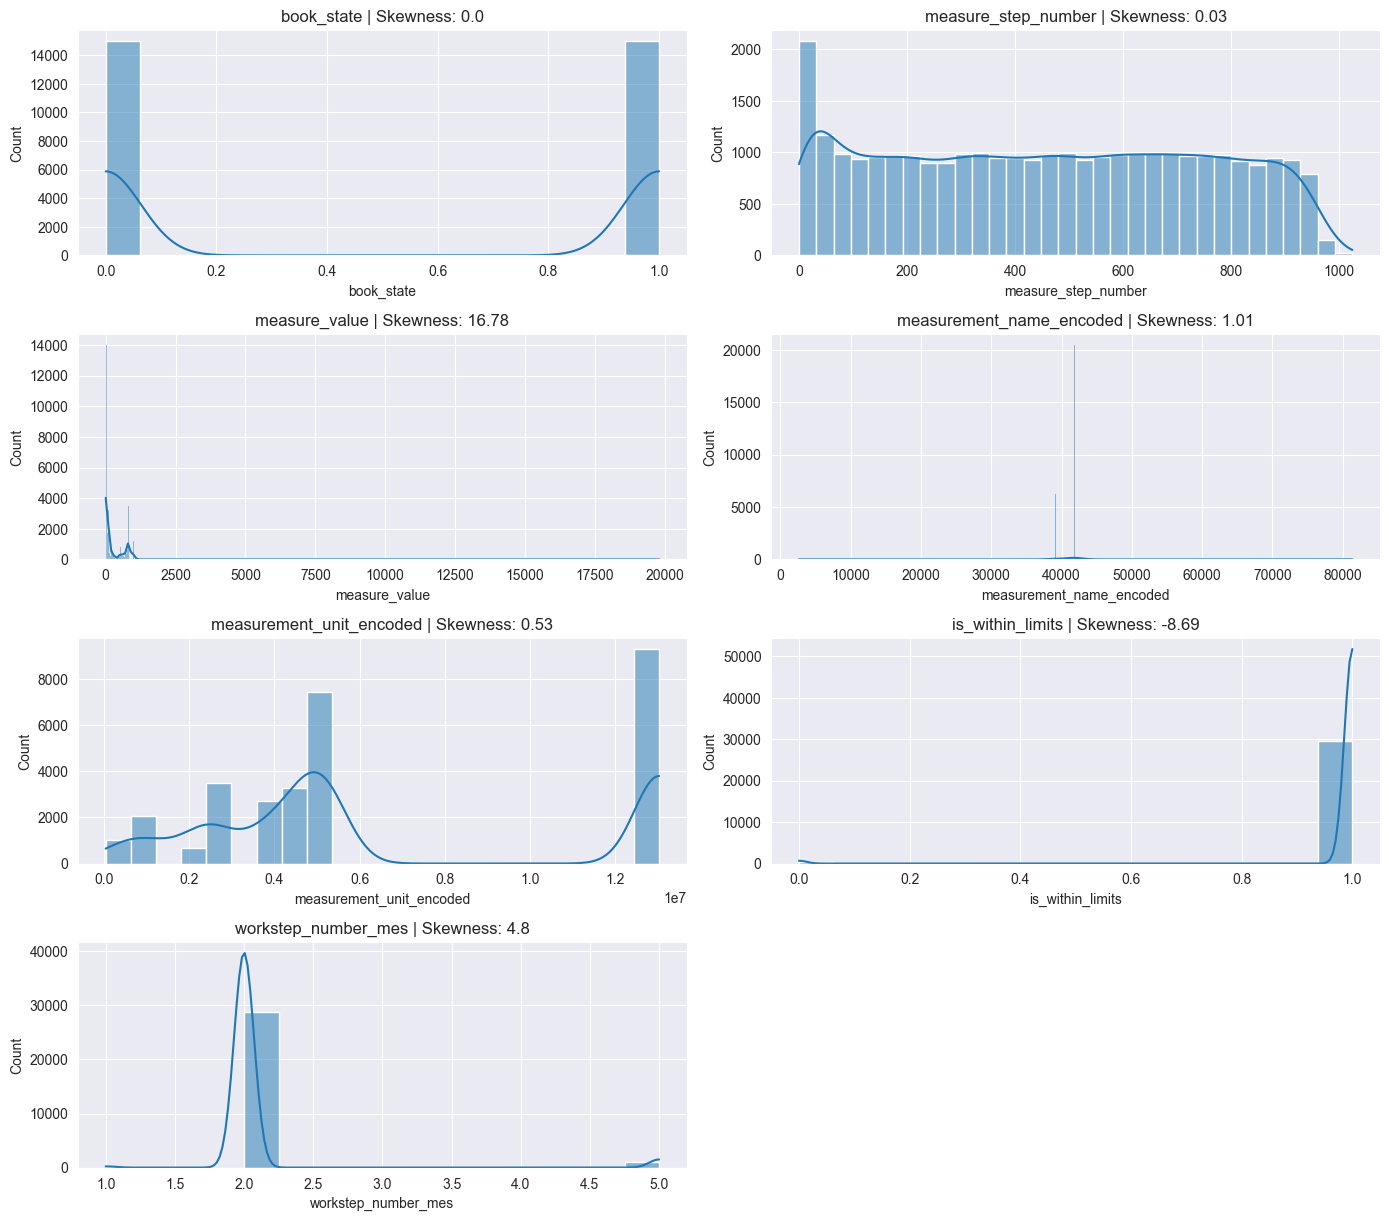

In [16]:
sns.set_style("darkgrid")

numerical_columns = df_bo_me.select_dtypes(include=["int32", "int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df_bo_me[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df_bo_me[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

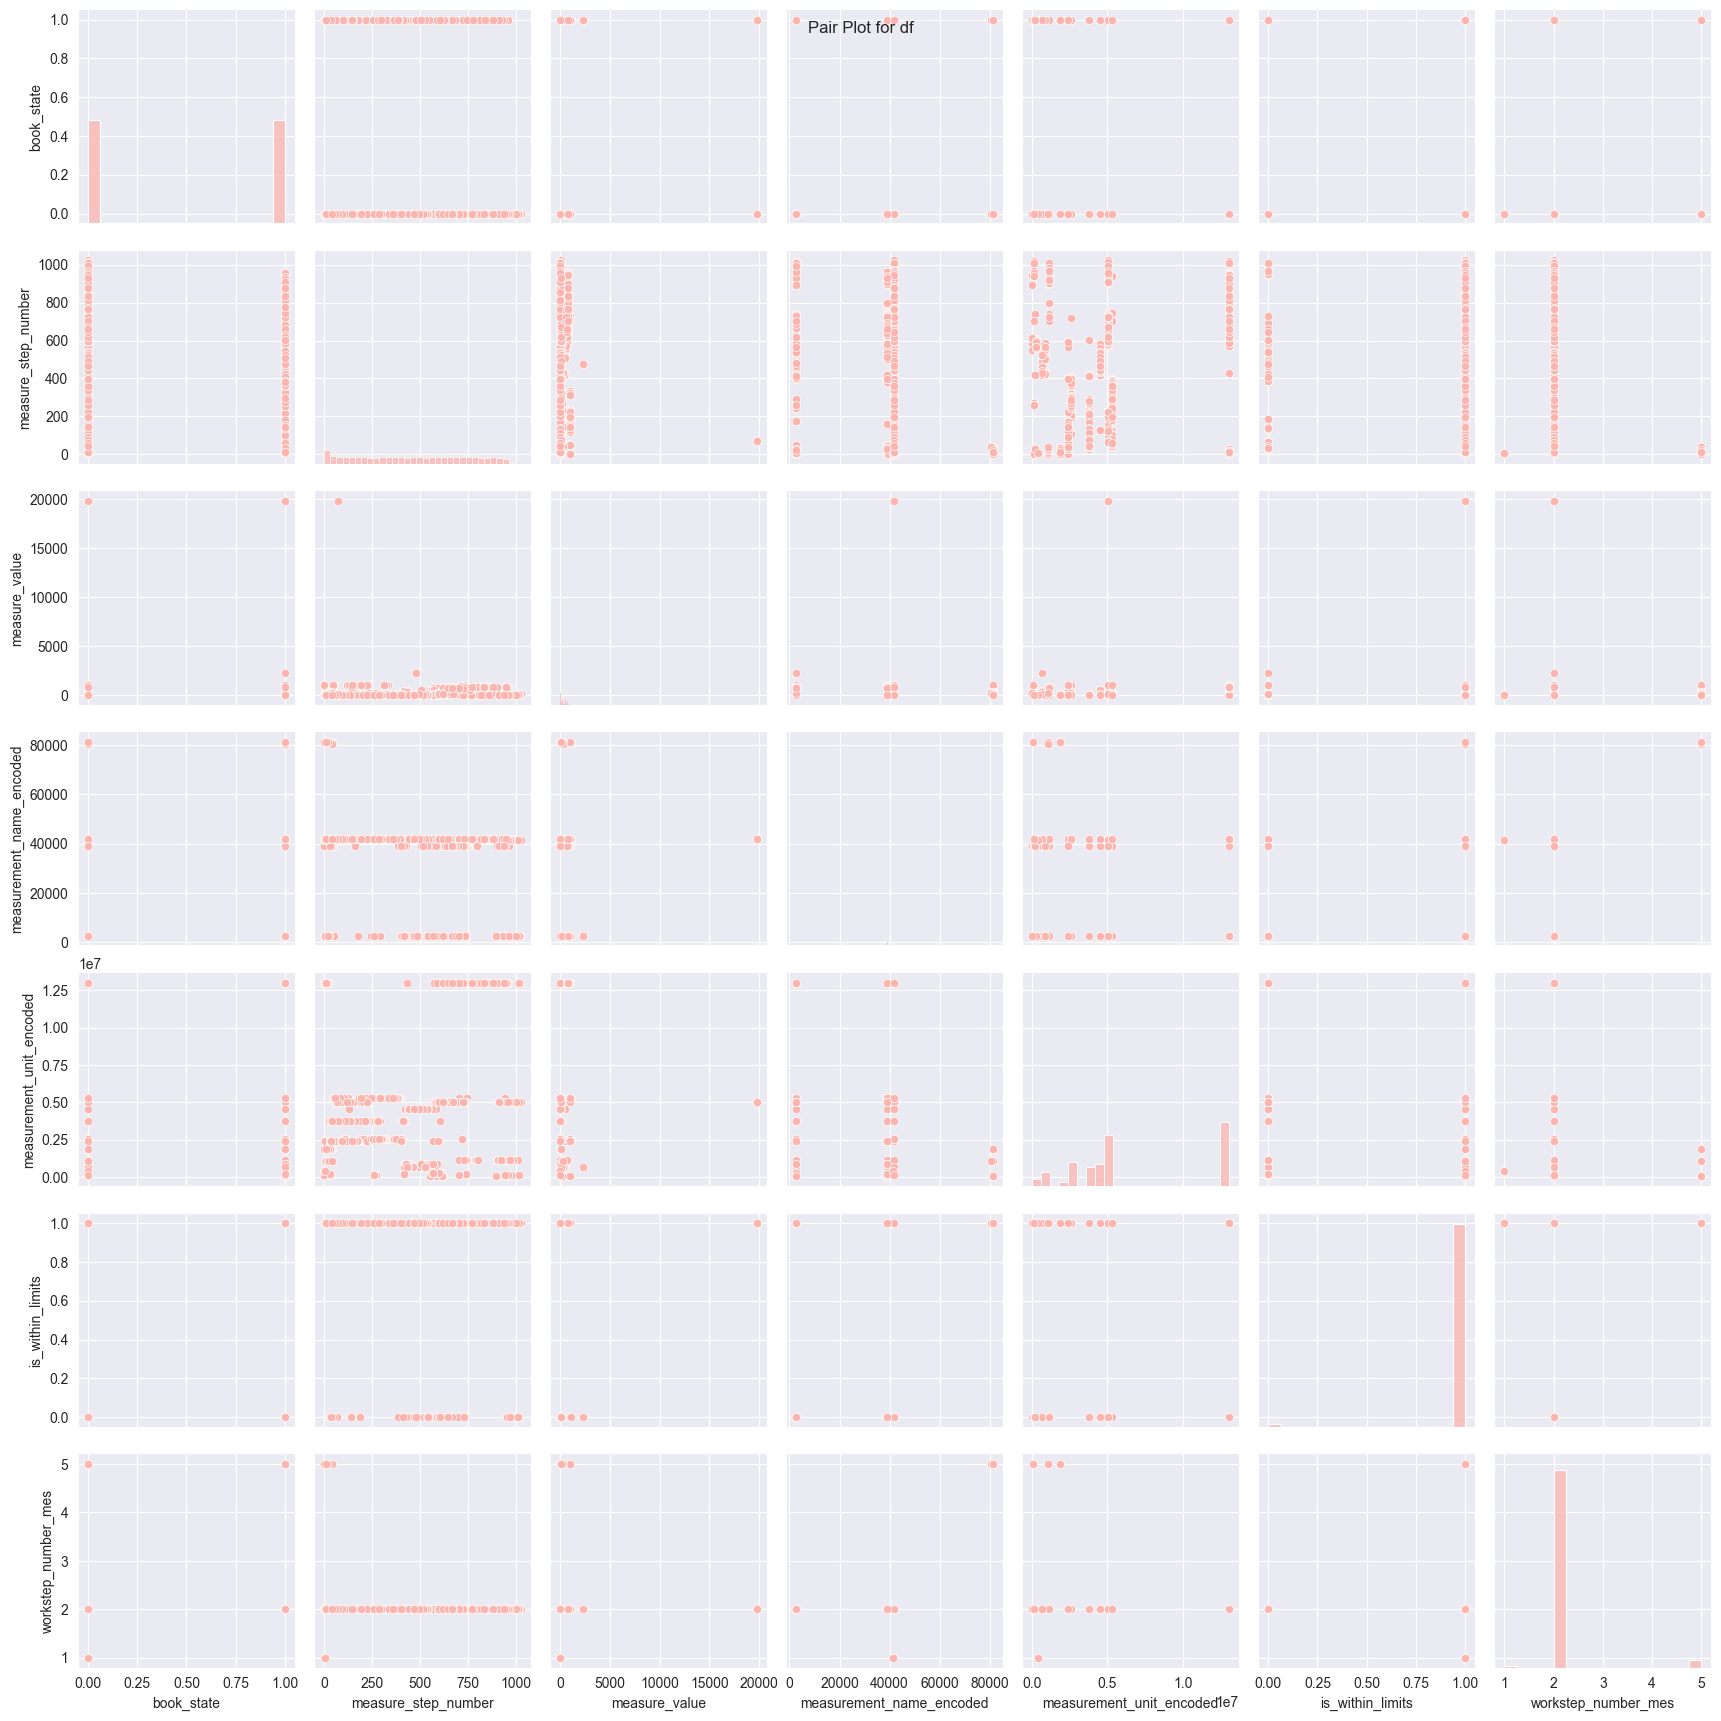

In [17]:
sns.set_palette("Pastel1")

plt.figure(figsize=(10, 6))

sns.pairplot(df_bo_me)

plt.suptitle('Pair Plot for df')
plt.show()

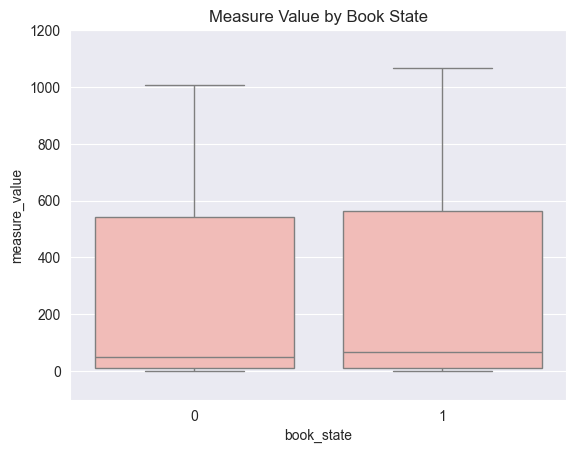

In [20]:
sns.boxplot(x='book_state', y='measure_value', data=df_bo_me)
plt.title("Measure Value by Book State")
plt.ylim(-100, 1200)
plt.show()

Text(0.5, 1.0, 'Distribution of measure_step_number by book_state')

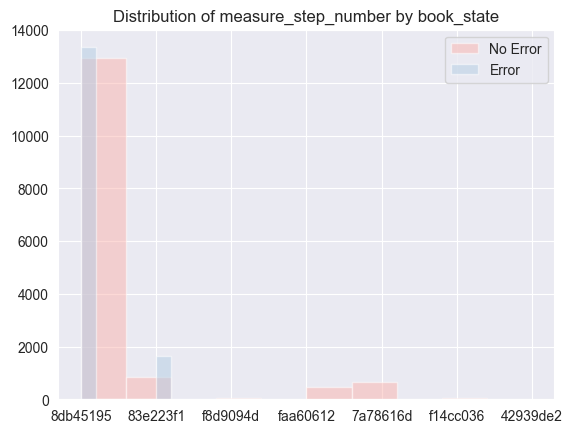

In [21]:
df_bo_me[df_bo_me['book_state'] == 0]['part_group'].hist(alpha=0.5, label='No Error')
df_bo_me[df_bo_me['book_state'] == 1]['part_group'].hist(alpha=0.5, label='Error')
plt.legend()
plt.title('Distribution of measure_step_number by book_state')

Text(0.5, 1.0, 'Distribution of measure_step_number by book_state')

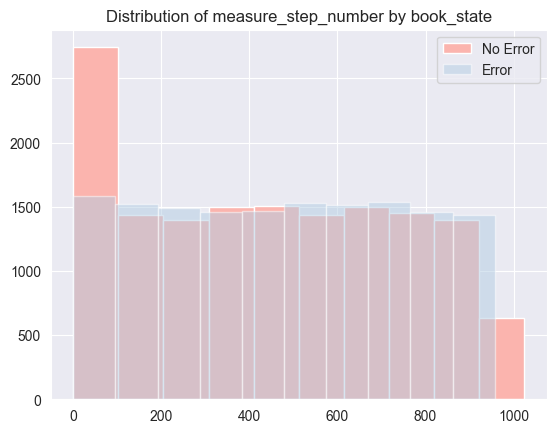

In [25]:
df_bo_me[df_bo_me['book_state'] == 0]['measure_step_number'].hist(alpha=1, label='No Error')
df_bo_me[df_bo_me['book_state'] == 1]['measure_step_number'].hist(alpha=0.5, label='Error')
plt.legend()
plt.title('Distribution of measure_step_number by book_state')

Text(0.5, 1.0, 'Error Rate by Station')

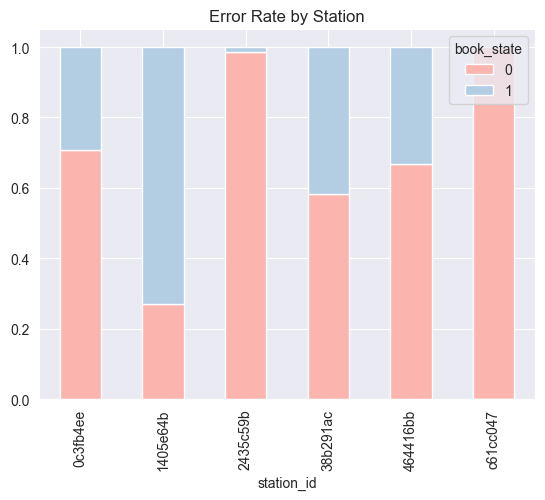

In [26]:
pd.crosstab(df_bo_me['station_id'], df_bo_me['book_state'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Error Rate by Station')

In [ ]:
pd.crosstab(df_bo_me['serial_number_id'], df_bo_me['book_state'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Error Rate by Serial Number')

In [28]:
pd.crosstab(df_bo_me['booking_id'], df_bo_me['book_state'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Error Rate by Serial Number')

Text(0.5, 1.0, 'Error Rate by Serial Number')

Error in callback <function _draw_all_if_interactive at 0x000001F7E90C81F0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x000001F78A5612D0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Text(0.5, 1.0, 'Correlation Matrix')

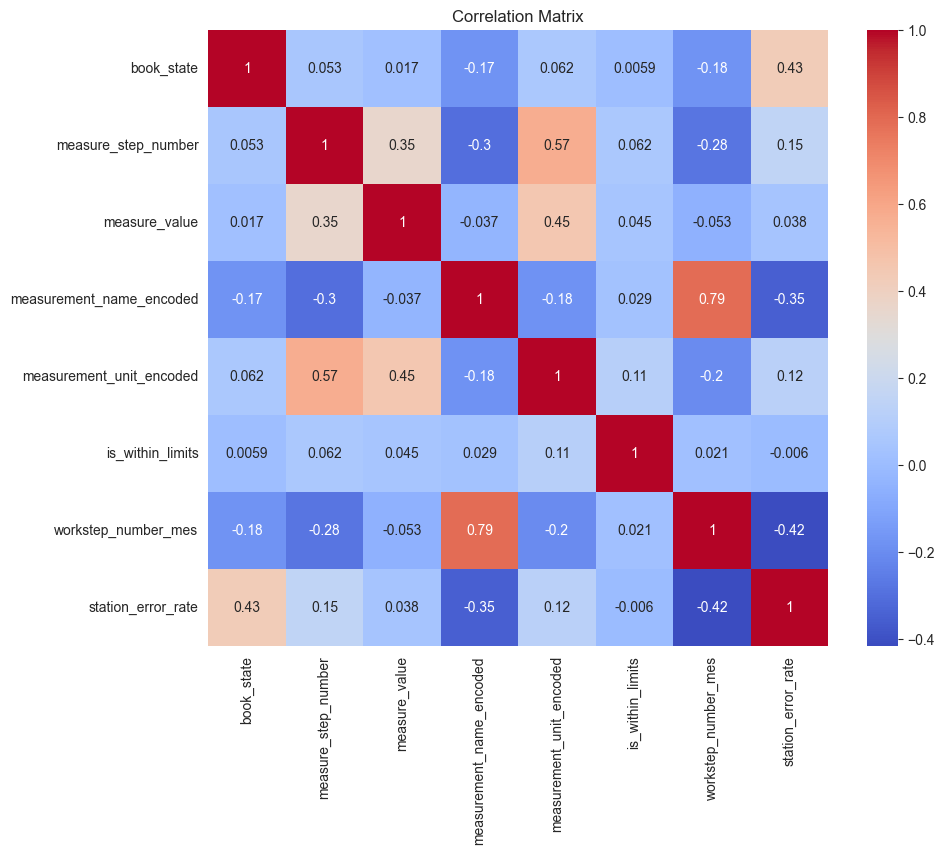

In [43]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_bo_me.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")

In [35]:
#error_rate_per_station = df_bo_me.groupby('station_id')['book_state'].mean()

# Merge
#df_bo_me['station_error_rate'] = df_bo_me['station_id'].map(error_rate_per_station)

In [36]:
#sns.boxplot(x='book_state', y='station_error_rate', data=df_bo_me)
#plt.title("Station Error Rate vs Book State")
#Haben fehlerhafte Teile höhere Station-Fehlerrate

# Visualisieren

In [34]:
station_ranking = df_bo_me.groupby('station_id')['book_state'].mean().sort_values(ascending=False)
print(station_ranking)  #höchste Fehlerquote

station_id
1405e64b    0.728953
38b291ac    0.416462
464416bb    0.332151
0c3fb4ee    0.291871
2435c59b    0.013787
c61cc047    0.000000
Name: book_state, dtype: float64


In [38]:
#sns.histplot(data=df_bo_me, x='station_error_rate', hue='book_state', kde=True, bins=30)
#plt.title("Distribution of Station Error Rate by Book State")

<Axes: xlabel='book_state', ylabel='measure_step_number'>

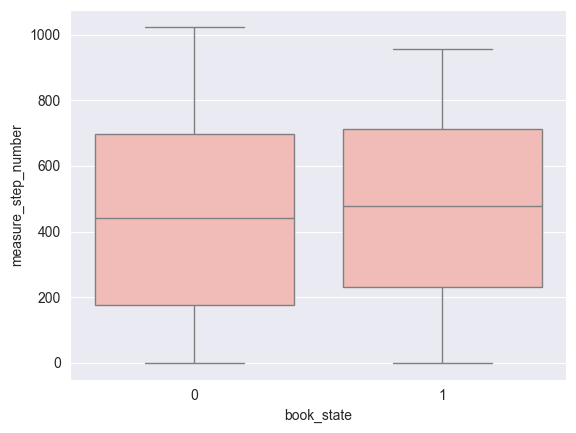

In [41]:
sns.boxplot(x='book_state', y='measure_step_number', data=df_bo_me)